In [1]:
import pandas as pd

# Load the SMS Spam Collection dataset
df = pd.read_csv(r"C:\Users\m.arasteh\data\bitcoin.csv",sep=",")

df["Open Time"] = pd.to_datetime(
    df["Open Time"],
    unit="ms"
)

df["Close Time"] = pd.to_datetime(
    df["Close Time"],
    unit="ms"
)

# Display the first five samples
df.head()

,Open Time,Open,High,Low,Close,Volume,Close Time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume
0,2021-01-01 00:00:00,28923.63,28961.66,28913.12,28961.66,27.457032,2021-01-01 00:00:59.999,7.943820e+05,1292,16.777195,485390.826825
1,2021-01-01 00:01:00,28961.67,29017.50,28961.01,29009.91,58.477501,2021-01-01 00:01:59.999,1.695803e+06,1651,33.733818,978176.468202
2,2021-01-01 00:02:00,29009.54,29016.71,28973.58,28989.30,42.470329,2021-01-01 00:02:59.999,1.231359e+06,986,13.247444,384076.854453
3,2021-01-01 00:03:00,28989.68,28999.85,28972.33,28982.69,30.360677,2021-01-01 00:03:59.999,8.800168e+05,959,9.456028,274083.075142
4,2021-01-01 00:04:00,28982.67,28995.93,28971.80,28975.65,24.124339,2021-01-01 00:04:59.999,6.992262e+05,726,6.814644,197519.374888


In [2]:
df = df[["Open Time", "Close"]]
df.head()

,Open Time,Close
0,2021-01-01 00:00:00,28961.66
1,2021-01-01 00:01:00,29009.91
2,2021-01-01 00:02:00,28989.30
3,2021-01-01 00:03:00,28982.69
4,2021-01-01 00:04:00,28975.65


In [3]:
df = df.rename(
    columns={"Open Time": "Date"}
)

In [4]:
df.set_index("Date", inplace=True)
df.head()

,Close
Date,
2021-01-01 00:00:00,28961.66
2021-01-01 00:01:00,29009.91
2021-01-01 00:02:00,28989.30
2021-01-01 00:03:00,28982.69
2021-01-01 00:04:00,28975.65


In [5]:
train_size = int(len(df) * 0.8)

train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

In [6]:
print("Total observations:", len(df))
print("Training observations:", len(train_data))
print("Test observations:", len(test_data))

Total observations: 188317
Training observations: 150653
Test observations: 37664


In [7]:
print("Training period:")
print(train_data.index.min())
print(train_data.index.max())

print("\nTest period:")
print(test_data.index.min())
print(test_data.index.max())

Training period:
2021-01-01 00:00:00
2021-04-15 17:41:00

Test period:
2021-04-15 17:42:00
2021-05-12 04:39:00


In [8]:
import matplotlib.pyplot as plt

def visualize_train_test(
    train_data,
    test_data,
    last_train_toShow = None,
    top_test_toShow = None,
    title="Training and Test Data",
    xlabel="Date",
    ylabel="Close Price",
    figsize=(14, 6)
):


    if last_train_toShow is not None:
        train_data = train_data[-last_train_toShow:]

    if top_test_toShow is not None:
        test_data = test_data[:top_test_toShow]

    plt.figure(figsize=figsize)

    # Plot training data
    plt.plot(train_data.index, train_data.values, label="Training")

    # Plot test data
    plt.plot(test_data.index, test_data.values, label="Test")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

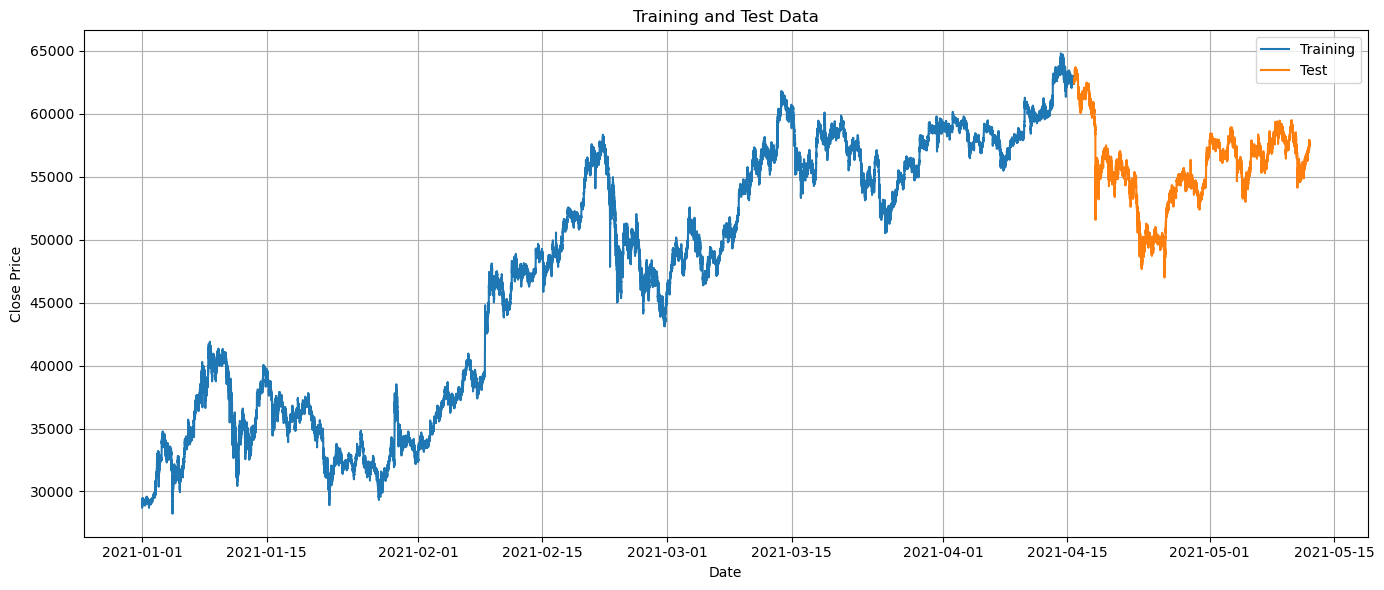

In [9]:
visualize_train_test(
    train_data,
    test_data
)

In [10]:
import numpy as np


def create_sliding_windows(data, window_size, horizon):
    X = []
    y = []

    # Calculate the number of samples
    num_samples = len(data) - window_size - horizon + 1

    for i in range(num_samples):

        # Input window
        input_window = data[
            i : i + window_size
        ]

        # Target horizon
        target = data[
            i + window_size :
            i + window_size + horizon
        ]

        X.append(input_window)
        y.append(target)

    return np.array(X), np.array(y)

In [11]:
# Example
data = np.array([
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100
])
window_size = 3
horizon = 1

X, y = create_sliding_windows(
    data,
    window_size = window_size,
    horizon = horizon
)

In [12]:
num_samples = len(data) - window_size - horizon + 1

for i in range(num_samples):
    print(X[i], "---->", y[i])

[10 20 30] ----> [40]
[20 30 40] ----> [50]
[30 40 50] ----> [60]
[40 50 60] ----> [70]
[50 60 70] ----> [80]
[60 70 80] ----> [90]
[70 80 90] ----> [100]


In [13]:
# Example

window_size = 4
horizon = 2
X, y = create_sliding_windows(
    data,
    window_size=window_size,
    horizon=horizon
)

num_samples = len(data) - window_size - horizon + 1

for i in range(num_samples):
    print(X[i], "---->", y[i])

[10 20 30 40] ----> [50 60]
[20 30 40 50] ----> [60 70]
[30 40 50 60] ----> [70 80]
[40 50 60 70] ----> [80 90]
[50 60 70 80] ----> [ 90 100]


In [14]:
train_values = train_data["Close"].values
test_values = test_data["Close"].values

In [15]:
# Example: creating sliding window on train dataset

window_size = 60
horizon = 7

X_train, y_train = create_sliding_windows(
    train_values,
    window_size=window_size,
    horizon=horizon
)

# For example print two top values
for i in range(2):
    print(X_train[i], "---->", y_train[i],"\n")

[28961.66 29009.91 28989.3  28982.69 28975.65 28937.11 28943.87 28934.84
 28900.   28858.94 28848.68 28824.35 28838.68 28706.64 28752.8  28769.77
 28810.   28800.57 28823.21 28820.72 28759.35 28796.23 28796.29 28835.01
 28846.46 28871.28 28844.48 28839.57 28833.96 28836.63 28875.75 28858.53
 28871.97 28890.   28880.38 28931.22 28928.7  28914.15 28901.91 28897.97
 28927.33 28913.45 28919.99 28916.93 28930.11 28894.49 28929.09 28938.76
 28939.61 28946.32 28951.45 28948.92 28965.99 28966.04 28947.1  28958.72
 28966.88 29015.4  29021.63 28995.13] ----> [28987.62 28972.26 28998.94 28988.15 29056.95 29089.33 29089.99] 

[29009.91 28989.3  28982.69 28975.65 28937.11 28943.87 28934.84 28900.
 28858.94 28848.68 28824.35 28838.68 28706.64 28752.8  28769.77 28810.
 28800.57 28823.21 28820.72 28759.35 28796.23 28796.29 28835.01 28846.46
 28871.28 28844.48 28839.57 28833.96 28836.63 28875.75 28858.53 28871.97
 28890.   28880.38 28931.22 28928.7  28914.15 28901.91 28897.97 28927.33
 28913.45 28919.9

In [16]:
# Example: creating sliding window on test dataset
window_size = 60
horizon = 7

X_test, y_test = create_sliding_windows(
    test_values,
    window_size=window_size,
    horizon=horizon
)
# For example print two top values
for i in range(2):
    print(X_test[i], "---->", y_test[i],"\n")

[62392.17 62391.22 62494.08 62519.11 62513.7  62529.21 62534.96 62521.65
 62495.19 62522.91 62511.83 62508.18 62527.   62497.28 62497.25 62492.98
 62541.11 62581.43 62593.53 62571.59 62575.01 62545.91 62533.16 62548.22
 62513.75 62543.99 62542.25 62587.41 62583.8  62608.38 62626.47 62572.92
 62574.63 62608.14 62590.5  62576.02 62576.55 62606.29 62618.06 62597.99
 62626.07 62611.42 62631.4  62635.55 62585.64 62597.95 62559.35 62523.33
 62561.36 62579.23 62620.74 62629.8  62620.72 62674.51 62699.99 62687.96
 62765.56 62822.84 62752.3  62722.09] ----> [62745.32 62768.6  62750.   62758.   62727.19 62720.09 62726.77] 

[62391.22 62494.08 62519.11 62513.7  62529.21 62534.96 62521.65 62495.19
 62522.91 62511.83 62508.18 62527.   62497.28 62497.25 62492.98 62541.11
 62581.43 62593.53 62571.59 62575.01 62545.91 62533.16 62548.22 62513.75
 62543.99 62542.25 62587.41 62583.8  62608.38 62626.47 62572.92 62574.63
 62608.14 62590.5  62576.02 62576.55 62606.29 62618.06 62597.99 62626.07
 62611.42 626

In [17]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (150587, 60)
y_train shape: (150587, 7)
X_test shape: (37598, 60)
y_test shape: (37598, 7)


In [18]:
import torch
import torch.nn as nn

class TimeSeriesModel(nn.Module):

    def __init__(self, window_size, horizon):
        super().__init__()

        self.layers = nn.Sequential(

            # Hidden layer
            nn.Linear(window_size, 64),
            nn.Linear(64, 128),

            # ReLU activation function
            nn.ReLU(),

            # Output layer
            nn.Linear(128, horizon)
        )

    def forward(self, x):
        return self.layers(x)

In [19]:
window_size = 60
horizon = 3

model_FFNN = TimeSeriesModel(
    window_size=window_size,
    horizon=horizon
)

In [20]:
print(model_FFNN)

TimeSeriesModel(
  (layers): Sequential(
    (0): Linear(in_features=60, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [21]:
# Create sliding winow on both train and test datasets
X_train, y_train = create_sliding_windows(
    train_values,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_values,
    window_size=window_size,
    horizon=horizon
)

In [22]:
# Before sending the data to a PyTorch model, we convert them to tensors:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([150591, 60])
y_train tensor shape: torch.Size([150591, 3])
X_test tensor shape: torch.Size([37602, 60])
y_test tensor shape: torch.Size([37602, 3])


In [23]:
from torch.utils.data import TensorDataset, DataLoader

def create_data_loaders(X_train, y_train, X_test, y_test, batch_size=128):
    """
    Create PyTorch DataLoaders for
    training and test datasets.
    """

    # Create TensorDatasets
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False  # to preserve the chronological order 
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False  # to preserve the chronological order 
    )

    return train_loader, test_loader

In [24]:
train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [25]:
# يheck the first batch:

X_batch, y_batch = next(iter(train_loader))

print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)

Input shape: torch.Size([128, 60])
Target shape: torch.Size([128, 3])


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [27]:
# Train model

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=100):

    # Move model to device
    model = model.to(device)

    # Store training history
    train_losses = []
    test_losses = []


    for epoch in range(epochs):

        # -----------------------
        # Training phase
        # -----------------------
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            predictions = model(inputs)

            # Compute MAE loss
            loss = criterion(predictions, targets)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Store batch loss
            running_loss += loss.item()


        # Average training loss
        epoch_train_loss = (running_loss / len(train_loader))

        # -----------------------
        # Evaluation phase
        # -----------------------
        model.eval()
        running_test_loss = 0.0

        # Disable gradient calculation
        with torch.no_grad():
            for inputs, targets in test_loader:

                # Move data to device
                inputs = inputs.to(device)
                targets = targets.to(device)

                # Forward pass
                predictions = model(inputs)

                # Compute MAE loss
                loss = criterion(predictions, targets)

                # Store batch loss
                running_test_loss += loss.item()


        # Average test loss
        epoch_test_loss = (running_test_loss / len(test_loader))

        # -----------------------
        # Store history
        # -----------------------
        train_losses.append(epoch_train_loss)
        test_losses.append(epoch_test_loss)

        # Print results
        if(epoch%20==0):
            print(
                f"Epoch [{epoch}/{epochs}] "
                f"Train MAE: {epoch_train_loss:.4f} "
                f"Test MAE: {epoch_test_loss:.4f}"
            )

    return train_losses, test_losses

In [28]:
# Loss function: MAE
criterion = nn.L1Loss()

# Optimizer: Adam
optimizer = torch.optim.Adam(
    model_FFNN.parameters(),
    lr=0.0001
)

In [29]:
train_losses_FFNN, test_losses_FFNN = train_model(
    model=model_FFNN,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 1049.0188 Test MAE: 239.8509
Epoch [20/100] Train MAE: 158.8281 Test MAE: 136.6347
Epoch [40/100] Train MAE: 139.2991 Test MAE: 110.3755
Epoch [60/100] Train MAE: 121.0811 Test MAE: 143.4267
Epoch [80/100] Train MAE: 114.6020 Test MAE: 173.6731


In [30]:

def plot_train_test_loss(
    train_losses,
    test_losses,
    title="Training and Test Loss",
    ylabel="Loss",
    figsize=(10, 5)
):
    """
    Plot training and test loss for each epoch.
    """

    # Create epoch numbers
    epochs = range(1, len(train_losses) + 1)


    # Create figure
    plt.figure(figsize=figsize)


    # Plot training loss
    plt.plot(epochs, train_losses, marker='o', label="Training Loss")

    # Plot test loss
    plt.plot(epochs, test_losses, marker='s', label="Test Loss")


    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

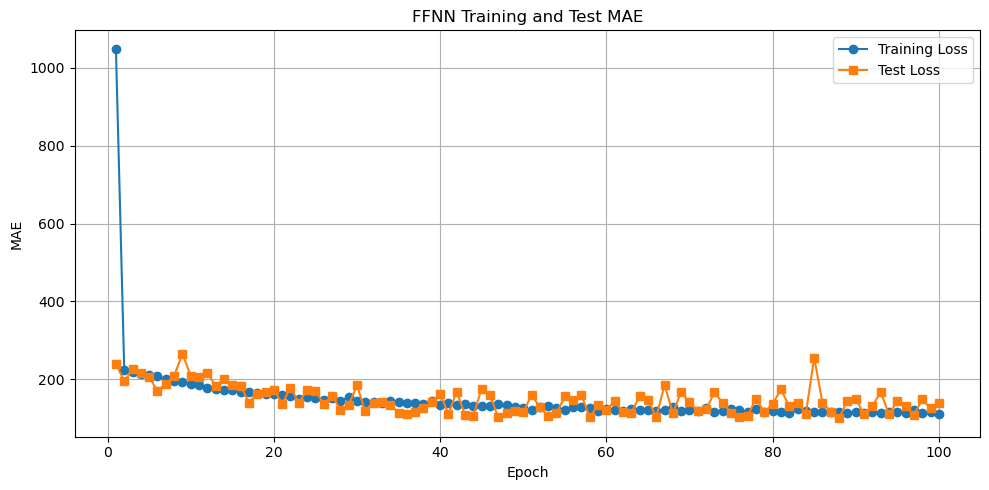

In [31]:
plot_train_test_loss(
    train_losses=train_losses_FFNN,
    test_losses=test_losses_FFNN,
    title="FFNN Training and Test MAE",
    ylabel="MAE"
)

In [32]:
import numpy as np
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


def evaluate_model(model, test_loader):
    """
    Evaluate a time-series forecasting model using:

    - MAE
    - MSE
    - RMSE
    - MAPE
    - sMAPE
    """

    # Move model to device
    model = model.to(device)

    # Set model to evaluation mode
    model.eval()

    predictions_list = []
    actual_list = []

    # Disable gradient calculation
    with torch.no_grad():

        for inputs, targets in test_loader:

            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Make predictions
            outputs = model(inputs)

            # Move tensors to CPU
            outputs = outputs.cpu().numpy()
            targets = targets.cpu().numpy()

            # Store predictions and targets
            predictions_list.append(outputs)
            actual_list.append(targets)


    # Combine all batches
    predictions = np.concatenate(
        predictions_list,
        axis=0
    )

    actual_values = np.concatenate(
        actual_list,
        axis=0
    )


    # Flatten arrays for horizon = 1
    predictions = predictions.flatten()
    actual_values = actual_values.flatten()

    # -----------------------------
    # Calculate MAE
    # -----------------------------
    mae = mean_absolute_error(actual_values, predictions)

    # -----------------------------
    # Calculate MSE
    # -----------------------------
    mse = mean_squared_error(actual_values, predictions)

    # -----------------------------
    # Calculate RMSE
    # -----------------------------
    rmse = np.sqrt(mse)

    # -----------------------------
    # Calculate MAPE
    # -----------------------------
    epsilon = 1e-8
    mape = np.mean(np.abs((actual_values - predictions) / (actual_values + epsilon))) * 100

    # -----------------------------
    # Calculate sMAPE
    # -----------------------------
    smape = np.mean(
        2 * np.abs(actual_values - predictions) / (np.abs(actual_values)
            +
            np.abs(predictions)
            +
            epsilon
        )
    ) * 100


    # Store all metrics
    metrics = {

        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": smape
    }


    # Print results
    print("\nModel Evaluation Results")
    print("-" * 30)

    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric}: {value:.4f}")



In [33]:
 evaluate_model(
    model=model_FFNN,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 137.6118
MSE: 30292.3691
RMSE: 174.0470
MAPE (%): 0.2476
sMAPE (%): 0.2479


In [34]:
def predict_next_price(model, data, window_size):

    # Move model to device
    model = model.to(device)

    # Set model to evaluation mode
    model.eval()

    # Get the latest window
    input_data = data[-window_size:]


    # Convert input to NumPy array
    input_data = np.asarray(input_data, dtype=np.float32)

    # Convert input to PyTorch tensor
    input_tensor = torch.tensor(input_data, dtype=torch.float32)

    # Add batch dimension
    input_tensor = input_tensor.unsqueeze(0)

    # Move input to device
    input_tensor = input_tensor.to(device)


    # Disable gradient calculation
    with torch.no_grad():
        prediction = model(input_tensor)


    # Convert prediction to NumPy
    prediction = prediction.cpu().numpy()

    return prediction

In [35]:
next_price = predict_next_price(
    model=model_FFNN,
    data=df["Close"],
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [57369.023 57385.664 57410.367]


In [36]:
class RNNModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=128,
        horizon=1
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers = 1,   # Number of RNN layers
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, horizon)


    def forward(self, x):

        # RNN output
        output, hidden = self.rnn(x)

        # Select the output from
        # the last time step
        output = output[:, -1, :]

        # Output layer
        output = self.fc(output)

        return output

In [37]:
window_size = 60
horizon = 3

In [38]:
# Create sliding winow on both train and test datasets
X_train, y_train = create_sliding_windows(
    train_values,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_values,
    window_size=window_size,
    horizon=horizon
)

In [39]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(150591, 60, 1)
(37602, 60, 1)


In [40]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([150591, 60, 1])
torch.Size([150591, 3])
torch.Size([37602, 60, 1])
torch.Size([37602, 3])


In [41]:
model_RNN = RNNModel(
    input_size=1,   # Number of features (We have just close price)
    hidden_size=128,
    horizon= horizon
)
print(model_RNN)

RNNModel(
  (rnn): RNN(1, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [42]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(
    model_RNN.parameters(),
    lr=0.02
)

In [43]:
train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [44]:
train_losses_RNN, test_losses_RNN = train_model(
    model=model_RNN,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 45550.2656 Test MAE: 52777.5776
Epoch [20/100] Train MAE: 9527.4640 Test MAE: 10786.6673
Epoch [40/100] Train MAE: 8925.0630 Test MAE: 6042.5142
Epoch [60/100] Train MAE: 8928.3968 Test MAE: 6021.8256
Epoch [80/100] Train MAE: 8928.4075 Test MAE: 6021.7403


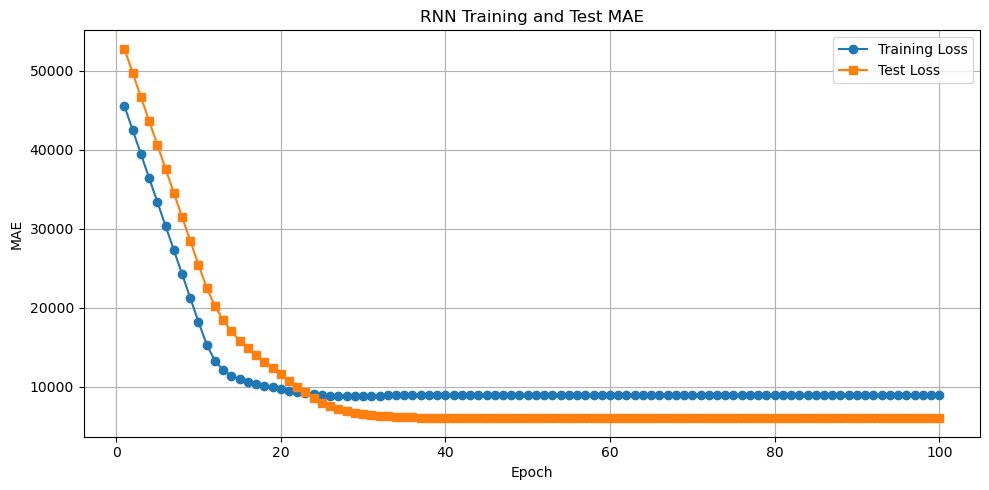

In [45]:
plot_train_test_loss(
    train_losses=train_losses_RNN,
    test_losses=test_losses_RNN,
    title="RNN Training and Test MAE",
    ylabel="MAE"
)

In [46]:
evaluate_model(
    model=model_RNN,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 6020.4712
MSE: 44692984.0000
RMSE: 6685.2811
MAPE (%): 10.5341
sMAPE (%): 11.2470


In [47]:
"""
Our previously created prediction function can also be reused, but there is one important difference.

The RNN requires the input shape:
(1, window_size, 1)
rather than:
(1, window_size)

Therefore, we should create an RNN-specific prediction function:
"""

def predict_next_price_RNN_TypeModels(
    model,
    data,
    window_size
):
    """
    Predict the next value using an RNN.
    """

    # Set model to evaluation mode
    model.eval()

    # Get the latest window
    input_data = data[-window_size:]

    # Convert to NumPy
    input_data = np.asarray(input_data, dtype=np.float32)

    # Add sequence feature dimension
    input_tensor = torch.tensor(
        input_data,
        dtype=torch.float32).reshape(1, window_size, 1)

    # Move to device
    input_tensor = input_tensor.to(device)

    # Make prediction
    with torch.no_grad():
        prediction = model(input_tensor)

    # Return a single value
    return prediction.squeeze()

In [48]:
next_price_RNN = predict_next_price_RNN_TypeModels(
    model=model_RNN,
    data=df["Close"],
    window_size=window_size
)

print(
    f"Predicted next Bitcoin closing price: "
    f"${next_price_RNN}"
)

Predicted next Bitcoin closing price: $tensor([49853.8164, 49854.5195, 49854.6406])


In [49]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(
        self,
        feature_size=1,
        hidden_size=128,
        horizon=1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=feature_size,
            hidden_size=hidden_size,
            num_layers=1,   # Number of LSTM layers
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )


    def forward(self, x):

        # LSTM output
        output, (hidden, cell) = self.lstm(x)

        # Select the output from
        # the last time step
        output = output[:, -1, :]

        # Output layer
        output = self.fc(output)

        return output

In [50]:
window_size = 60
horizon = 3

In [51]:
# Create sliding winow on both train and test datasets
X_train, y_train = create_sliding_windows(
    train_values,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_values,
    window_size=window_size,
    horizon=horizon
)

In [52]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(150591, 60, 1)
(37602, 60, 1)


In [53]:
# Before sending the data to a PyTorch model, we convert them to tensors:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([150591, 60, 1])
y_train tensor shape: torch.Size([150591, 3])
X_test tensor shape: torch.Size([37602, 60, 1])
y_test tensor shape: torch.Size([37602, 3])


In [54]:
train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=64
)

In [55]:
model_LSTM = LSTMModel(
    feature_size=1,
    hidden_size=128,
    horizon=horizon
)

In [56]:
print(model_LSTM)

LSTMModel(
  (lstm): LSTM(1, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [57]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_LSTM.parameters(),
    lr=0.02
)

In [58]:
train_losses_LSTM, test_losses_LSTM = train_model(
    model=model_LSTM,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 46343.9691 Test MAE: 54380.3940
Epoch [20/100] Train MAE: 17655.7346 Test MAE: 25691.4819
Epoch [40/100] Train MAE: 9903.0500 Test MAE: 12507.9212
Epoch [60/100] Train MAE: 8898.9863 Test MAE: 7265.5551
Epoch [80/100] Train MAE: 8907.1625 Test MAE: 6619.4617


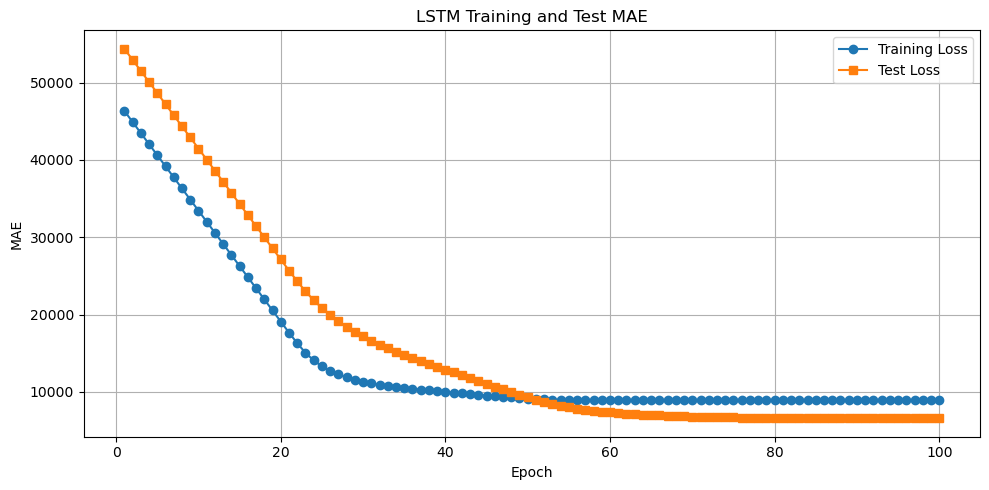

In [59]:
plot_train_test_loss(
    train_losses=train_losses_LSTM,
    test_losses=test_losses_LSTM,
    title="LSTM Training and Test MAE",
    ylabel="MAE"
)

In [60]:
evaluate_model(
    model=model_LSTM,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 6581.8418
MSE: 52221372.0000
RMSE: 7226.4356
MAPE (%): 11.5332
sMAPE (%): 12.3748


In [61]:
next_price_LSTM = predict_next_price_RNN_TypeModels(
    model=model_LSTM,
    data=df["Close"],
    window_size=window_size
)

print(
    f"Predicted next Bitcoin closing price: "
    f"${next_price_LSTM}"
)

Predicted next Bitcoin closing price: $tensor([49252.6914, 49252.9453, 49253.1758])


In [62]:
class GRUModel(nn.Module):

    def __init__(
        self,
        feature_size=1,
        hidden_size=128,
        horizon=1
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=feature_size,
            hidden_size=hidden_size,
            num_layers=1,   # Number of GRU layers
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )


    def forward(self, x):

        # GRU output
        output, hidden = self.gru(x)

        # Select the output from
        # the last time step
        output = output[:, -1, :]

        # Output layer
        output = self.fc(output)

        return output

In [63]:
window_size = 60
horizon = 3

In [64]:
# Create sliding winow on both train and test datasets
X_train, y_train = create_sliding_windows(
    train_values,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_values,
    window_size=window_size,
    horizon=horizon
)

In [65]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(150591, 60, 1)
(37602, 60, 1)


In [66]:
# Before sending the data to a PyTorch model, we convert them to tensors:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([150591, 60, 1])
y_train tensor shape: torch.Size([150591, 3])
X_test tensor shape: torch.Size([37602, 60, 1])
y_test tensor shape: torch.Size([37602, 3])


In [67]:
train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=64
)

In [68]:
model_GRU = GRUModel(
    feature_size=1,
    hidden_size=128,
    horizon=horizon
)

In [69]:
print(model_GRU)

GRUModel(
  (gru): GRU(1, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [70]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_GRU.parameters(),
    lr=0.02
)

In [71]:
train_losses_GRU, test_losses_GRU = train_model(
    model=model_GRU,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 45602.3856 Test MAE: 52896.5918
Epoch [20/100] Train MAE: 9687.8705 Test MAE: 11479.2155
Epoch [40/100] Train MAE: 8910.6280 Test MAE: 6085.4173
Epoch [60/100] Train MAE: 8915.8775 Test MAE: 6050.8814
Epoch [80/100] Train MAE: 8915.8823 Test MAE: 6050.8544


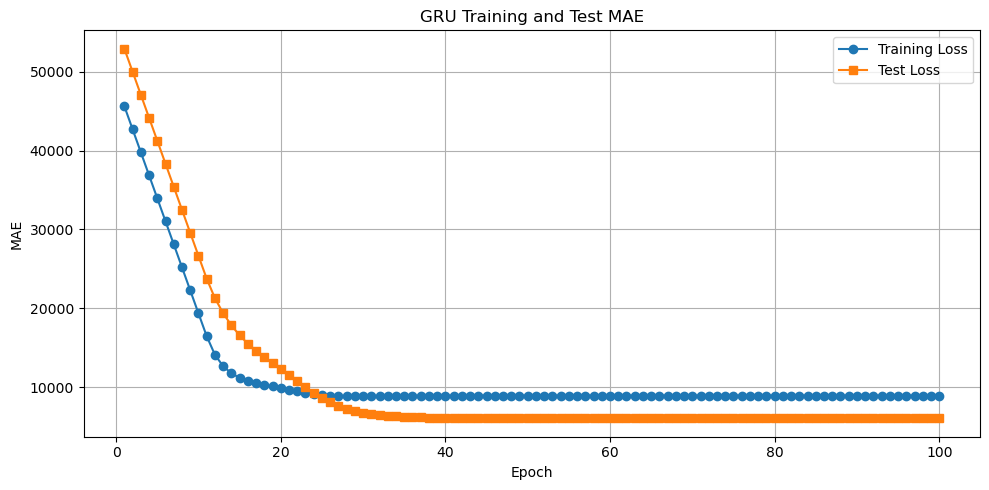

In [72]:
plot_train_test_loss(
    train_losses=train_losses_GRU,
    test_losses=test_losses_GRU,
    title="GRU Training and Test MAE",
    ylabel="MAE"
)

In [73]:
evaluate_model(
    model=model_GRU,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 6049.3779
MSE: 45076920.0000
RMSE: 6713.9348
MAPE (%): 10.5853
sMAPE (%): 11.3047


In [74]:
next_price_GRU = predict_next_price_RNN_TypeModels(
    model=model_GRU,
    data=df["Close"],
    window_size=window_size
)

print(
    f"Predicted next Bitcoin closing price: "
    f"${next_price_GRU}"
)

Predicted next Bitcoin closing price: $tensor([49822.1289, 49822.1523, 49822.3047])


In [75]:
class Conv1DModel(nn.Module):

    def __init__(
        self,
        feature_size=1,
        window_size=60,
        horizon=1,
        out_channels=128,
        kernel_size=5
    ):
        super().__init__()

        # First Conv1D layer
        self.conv1 = nn.Conv1d(
            in_channels=feature_size,
            out_channels=out_channels,
            kernel_size=kernel_size,
        )

        # Second Conv1D layer
        self.conv2 = nn.Conv1d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
        )

        self.relu = nn.ReLU()

        # Calculate the output size after two Conv1D layers
        conv_output_size = window_size - 2 * (kernel_size - 1)

        self.fc = nn.Linear(
            out_channels * conv_output_size,
            horizon
        )


    def forward(self, x):

        # First Conv1D
        output = self.conv1(x)

        # ReLU activation
        output = self.relu(output)

        # Second Conv1D
        output = self.conv2(output)

        # ReLU activation
        output = self.relu(output)

        # Flatten
        output = output.reshape(
            output.size(0),
            -1
        )

        # Output layer
        output = self.fc(output)

        return output

In [76]:
window_size = 60
horizon = 3

In [77]:
X_train, y_train = create_sliding_windows(
    train_values,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_values,
    window_size=window_size,
    horizon=horizon
)

In [78]:
X_train = X_train.reshape(X_train.shape[0],1,  X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print(X_train.shape)
print(X_test.shape)

(150591, 1, 60)
(37602, 1, 60)


In [79]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([150591, 1, 60])
y_train tensor shape: torch.Size([150591, 3])
X_test tensor shape: torch.Size([37602, 1, 60])
y_test tensor shape: torch.Size([37602, 3])


In [80]:
train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=64
)

In [81]:
model_Conv1D = Conv1DModel(
    feature_size=1,
    window_size=window_size,
    horizon=horizon,
    out_channels=128,
    kernel_size=7
)

In [82]:
print(model_Conv1D)

Conv1DModel(
  (conv1): Conv1d(1, 128, kernel_size=(7,), stride=(1,))
  (conv2): Conv1d(128, 128, kernel_size=(7,), stride=(1,))
  (relu): ReLU()
  (fc): Linear(in_features=6144, out_features=3, bias=True)
)


In [83]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_Conv1D.parameters(),
    lr=0.0005
)

In [84]:
train_losses_Conv1D, test_losses_Conv1D = train_model(
    model=model_Conv1D,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 1082.0722 Test MAE: 637.6991
Epoch [20/100] Train MAE: 322.2180 Test MAE: 271.8701
Epoch [40/100] Train MAE: 265.5105 Test MAE: 155.1702
Epoch [60/100] Train MAE: 225.2613 Test MAE: 157.1194
Epoch [80/100] Train MAE: 192.5955 Test MAE: 225.0293


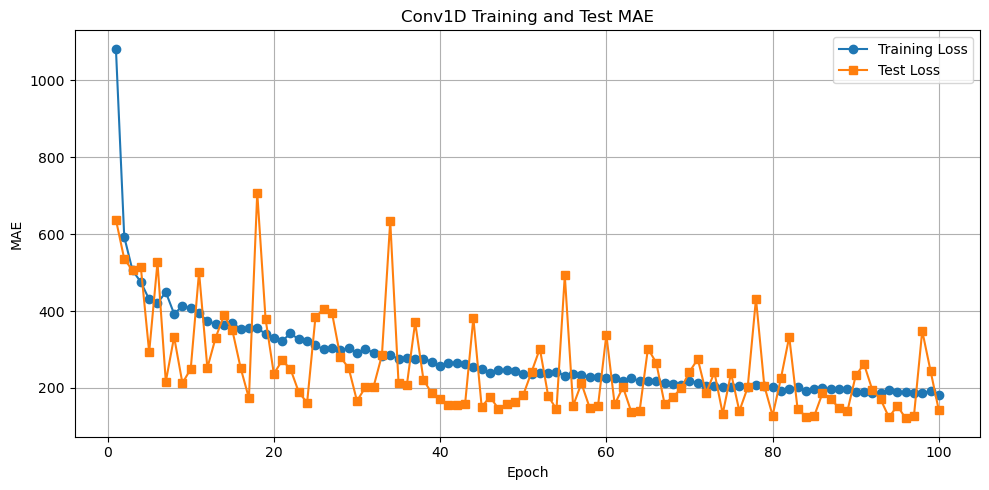

In [85]:
plot_train_test_loss(
    train_losses=train_losses_Conv1D,
    test_losses=test_losses_Conv1D,
    title="Conv1D Training and Test MAE",
    ylabel="MAE"
)

In [86]:
evaluate_model(
    model=model_Conv1D,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 141.6335
MSE: 38436.4961
RMSE: 196.0523
MAPE (%): 0.2556
sMAPE (%): 0.2559


In [87]:
"""
Our RNN, LSTM, and GRU models require the input shape:

(1, window_size, 1)

However, Conv1D requires:

(1, 1, window_size)

Therefore, we use a Conv1D-specific prediction function:
"""

def predict_next_price_Conv1D(model, data, window_size):

    # Set model to evaluation mode
    model.eval()

    # Get the latest window
    input_data = data[-window_size:]

    # Convert to NumPy
    input_data = np.asarray(input_data, dtype=np.float32)

    # Convert to tensor
    input_tensor = torch.tensor(input_data, dtype=torch.float32)

    # Reshape:
    # (window_size)
    #       ↓
    # (1, 1, window_size)
    input_tensor = input_tensor.reshape(1, 1,  window_size)

    # Move to device
    input_tensor = input_tensor.to(device)

    # Make prediction
    with torch.no_grad():
        prediction = model(input_tensor)

    # Return a single value
    return prediction.squeeze()

In [88]:
next_price_Conv1D = predict_next_price_Conv1D(
    model=model_Conv1D,
    data=df["Close"],
    window_size=window_size
)

print(
    f"Predicted next Bitcoin closing price: "
    f"${next_price_Conv1D:}"
)

Predicted next Bitcoin closing price: $tensor([57503.3750, 57531.8711, 57513.7109])


In [89]:
import torch
import torch.nn as nn


class NBeatsBlock(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        theta_size,
        backcast_size,
        forecast_size
    ):
        super().__init__()

        self.fc_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        self.theta = nn.Linear(
            hidden_size,
            theta_size
        )

        self.backcast_linear = nn.Linear(
            theta_size,
            backcast_size
        )

        self.forecast_linear = nn.Linear(
            theta_size,
            forecast_size
        )

    def forward(self, x):

        x = self.fc_stack(x)

        theta = self.theta(x)

        backcast = self.backcast_linear(theta)

        forecast = self.forecast_linear(theta)

        return backcast, forecast

In [90]:
class NBeats(nn.Module):

    def __init__(
        self,
        window_size,
        horizon,
        hidden_size=256,
        theta_size=128,
        num_blocks=4
    ):
        super().__init__()

        self.blocks = nn.ModuleList([
            NBeatsBlock(
                input_size=window_size,
                hidden_size=hidden_size,
                theta_size=theta_size,
                backcast_size=window_size,
                forecast_size=horizon
            )
            for _ in range(num_blocks)
        ])

    def forward(self, x):

        residual = x

        forecast = torch.zeros(
            x.size(0),
            self.blocks[0].forecast_linear.out_features,
            device=x.device
        )

        for block in self.blocks:

            backcast, block_forecast = block(residual)

            residual = residual - backcast

            forecast = forecast + block_forecast

        return forecast

In [91]:
window_size = 60
horizon = 3

In [92]:
X_train, y_train = create_sliding_windows(
    train_values,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_values,
    window_size=window_size,
    horizon=horizon
)

In [93]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([150591, 60])
y_train tensor shape: torch.Size([150591, 3])
X_test tensor shape: torch.Size([37602, 60])
y_test tensor shape: torch.Size([37602, 3])


In [94]:
train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=64
)

In [95]:
model_N_BEATS = NBeats(
    window_size=window_size,
    horizon=horizon,
    hidden_size=256,
    theta_size=128,
    num_blocks=4
)

In [96]:
print(model_N_BEATS)

NBeats(
  (blocks): ModuleList(
    (0-3): 4 x NBeatsBlock(
      (fc_stack): Sequential(
        (0): Linear(in_features=60, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): ReLU()
        (6): Linear(in_features=256, out_features=256, bias=True)
        (7): ReLU()
      )
      (theta): Linear(in_features=256, out_features=128, bias=True)
      (backcast_linear): Linear(in_features=128, out_features=60, bias=True)
      (forecast_linear): Linear(in_features=128, out_features=3, bias=True)
    )
  )
)


In [97]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_N_BEATS.parameters(),
    lr=0.0005
)

In [98]:
train_losses_N_BEATS, test_losses_N_BEATS = train_model(
    model=model_N_BEATS,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 743.1041 Test MAE: 324.6208
Epoch [20/100] Train MAE: 124.8464 Test MAE: 86.5862
Epoch [40/100] Train MAE: 86.9174 Test MAE: 67.7856
Epoch [60/100] Train MAE: 78.2196 Test MAE: 141.5248
Epoch [80/100] Train MAE: 75.4491 Test MAE: 65.4854


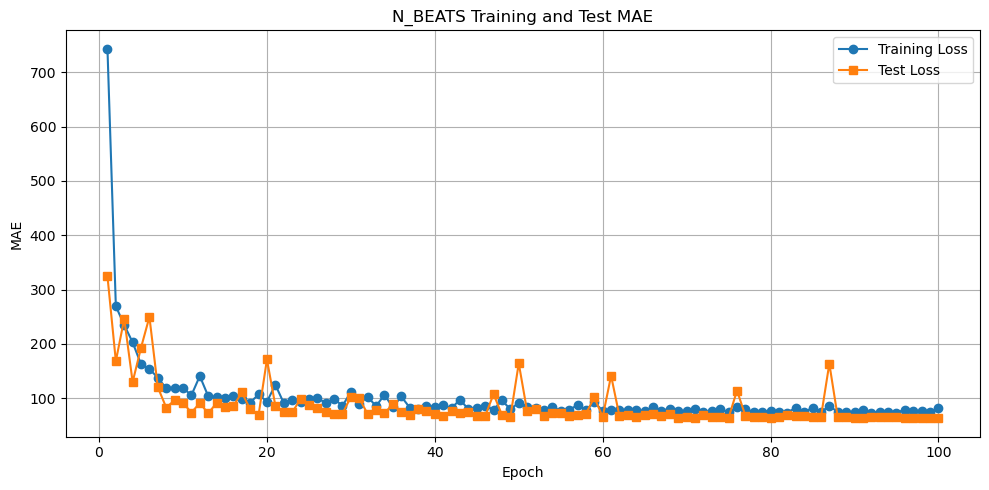

In [99]:
plot_train_test_loss(
    train_losses=train_losses_N_BEATS,
    test_losses=test_losses_N_BEATS,
    title="N_BEATS Training and Test MAE",
    ylabel="MAE"
)

In [100]:
evaluate_model(
    model=model_N_BEATS,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 63.2183
MSE: 9362.6592
RMSE: 96.7608
MAPE (%): 0.1144
sMAPE (%): 0.1144


In [101]:
# Since in N-BEATS data shape is not changde and it is as FFNN we can use predict_next_price function that was introduced in FFNN model

next_price = predict_next_price(
    model=model_N_BEATS,
    data=df["Close"],
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [57467.375 57467.89  57455.7  ]
